# Analyzing Software Engineering as a Lifecycle Process
- Modeling and concept mapping
- State extraction
- Utility experiment


## 1. Load DuckDB and build weekly counts


Dataset: commitizen
DuckDB: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\commitizen.duckdb
OCEL2: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\ocel2_commitizen.sqlite
Closed event type id: 105


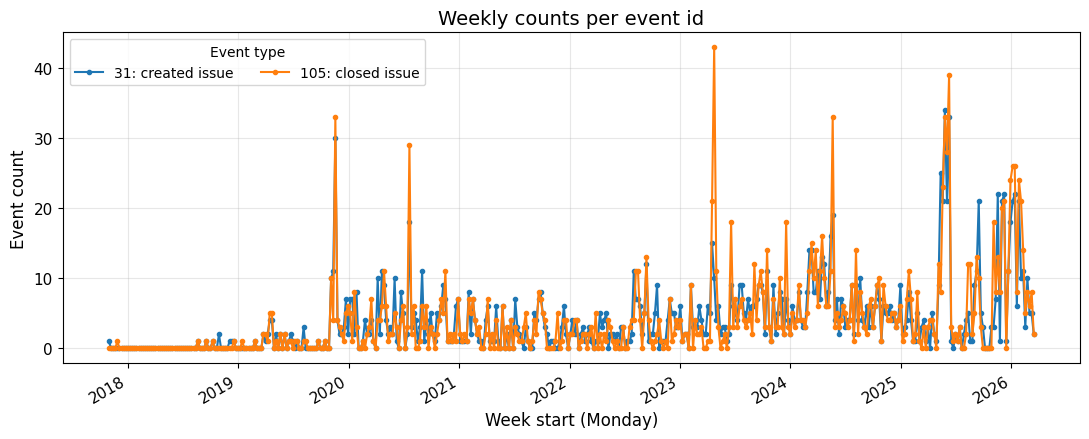

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\commitizen\weekly_open_closed_summary.csv


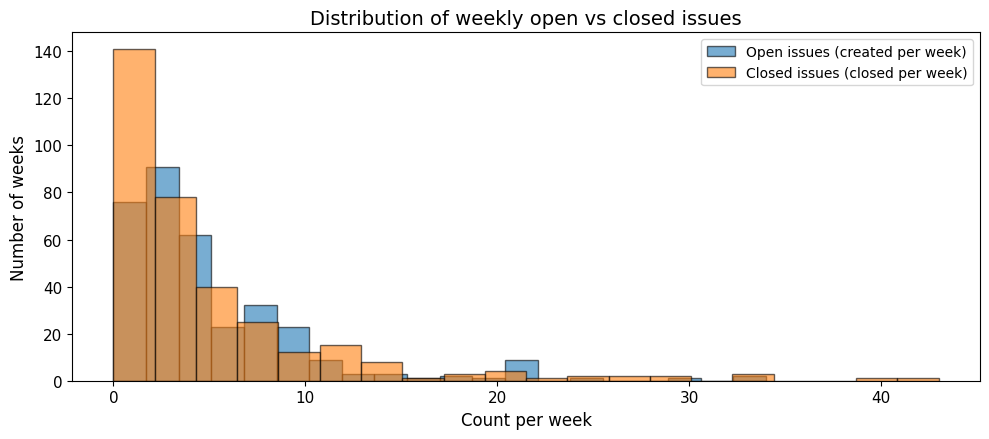

,Open issues (weekly created),Closed issues (weekly closed)
count,339.00,339.00
mean,5.04,5.10
std,5.19,6.37
min,0.00,0.00
25%,2.00,1.00
50%,4.00,3.00
75%,7.00,6.00
max,34.00,43.00


In [1]:
from pathlib import Path

from functions.configs import load_dataset_config
from functions.data_loading import (
    build_weekly_issue_counts,
    load_events_per_obj,
    load_objects_attributes,
)
from functions.plotting_anomaly import (
    plot_weekly_event_counts,
    plot_weekly_open_vs_closed_histogram,
    weekly_open_closed_summary_table,
)

# The only dataset-specific line in this notebook.
cfg = load_dataset_config("commitizen")

cfg.tables_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_no_titles_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", cfg.dataset_name)
print("DuckDB:", cfg.duckdb_path)
print("OCEL2:", cfg.sqlite_path)
print("Closed event type id:", cfg.closed_event_type_id)

eventsPerobj_df = load_events_per_obj(cfg)
objects_attributes = load_objects_attributes(cfg)
weekly = build_weekly_issue_counts(eventsPerobj_df, cfg)
plot_weekly_event_counts(weekly, cfg)
summary_table = weekly_open_closed_summary_table(weekly, cfg)
plot_weekly_open_vs_closed_histogram(weekly, cfg)
summary_table


## 2. Rolling IQR + lexicon state extraction


In [2]:
from functions.anomaly_pipeline import run_anomaly_state_extraction

weekly_closed_anomaly_frame, anomaly_context, anomaly_states, event_closed_title_join = (
    run_anomaly_state_extraction(weekly, eventsPerobj_df, objects_attributes, cfg)
)
anomaly_states.head()


Detected 25 rolling-IQR anomalies for event_type_id=105.
Joined title attribute rows: 1729 of 1729 event rows.
Saved anomaly states to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\commitizen\anomaly_states.csv


,week_start,value,is_anomaly,anomaly_direction,anomaly_score,lower_bound,upper_bound,title_count,event_count,severity,component,reasoning,extraction_method,confidence,event_descriptions,titles_in_week
0,2019-04-15,5,True,high,3.833333,-0.875,2.125,5,5,P4,documentation,Weekly closures show a well beyond-typical spi...,rule_based,0.736905,"[closed (#19), closed (#15), closed (#17), clo...","[fix(bump): prefixes like docs, build, etc no ..."
1,2019-04-22,5,True,high,6.500000,-0.250,1.750,4,5,P4,version & bump,Weekly closures show a well beyond-typical spi...,rule_based,0.688929,"[closed (#23), closed (#20), closed (#21), clo...",[fix(bump): handle commit and create tag failu...
2,2019-05-20,2,True,high,0.000000,1.000,1.000,2,2,P3,dependencies,Weekly closures show a near-typical spike (2 v...,rule_based,0.772500,"[closed (#26), closed (#27)]",[chore(deps-dev): update black requirement fro...
3,2019-11-04,10,True,high,0.000000,1.000,1.000,10,10,P3,build & ci,Weekly closures show a near-typical spike (10 ...,rule_based,0.664167,"[closed (#32), closed (#41), closed (#7), clos...","[Handle git tag failure, feat(commit): new ret..."
4,2019-11-11,4,True,high,0.000000,1.000,1.000,4,4,P2,build & ci,Weekly closures show a near-typical spike (4 v...,rule_based,0.550417,"[closed (#46), closed (#51), closed (#50), clo...",[Exception occurs when subject is not provided...


## 3. Export anomaly object / event IDs


In [3]:
from functions.anomaly_ids import export_anomaly_ids

anomaly_object_ids, anomaly_event_ids = export_anomaly_ids(anomaly_context, cfg)
anomaly_object_ids.head()



,week_start,object_id
0,2019-04-15,116370
1,2019-04-15,116396
2,2019-04-15,116442
3,2019-04-15,116518
4,2019-04-15,116547


## 4. Anomaly plots


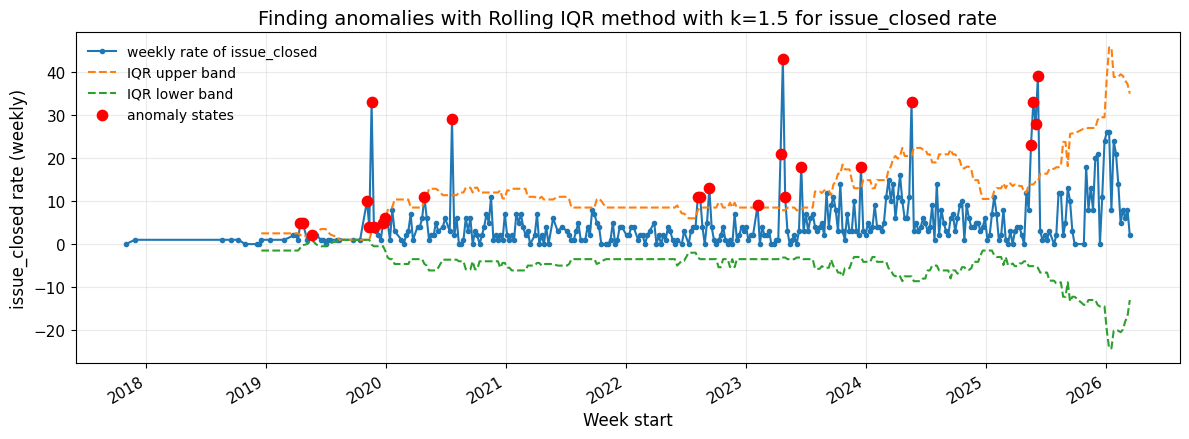

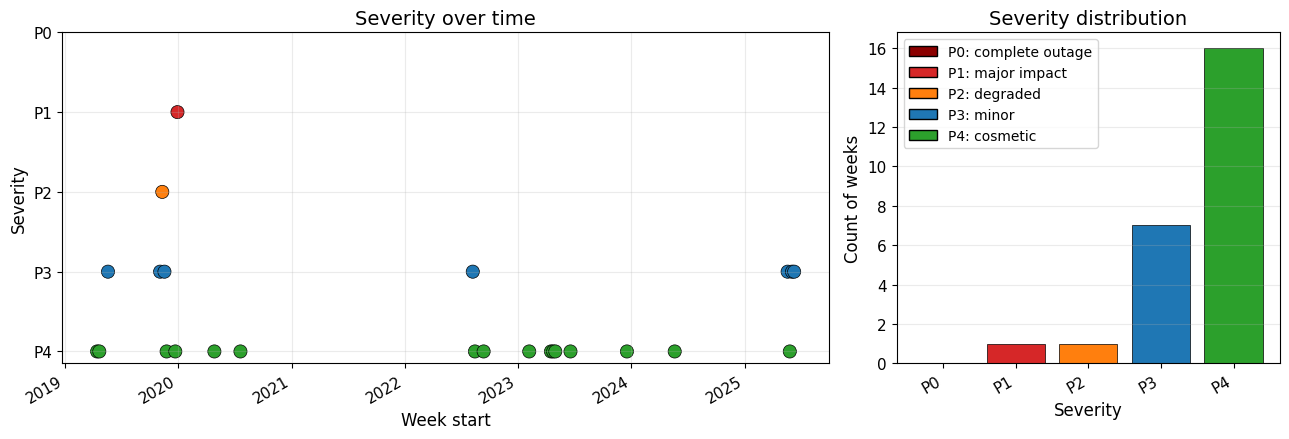

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:397: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 1])


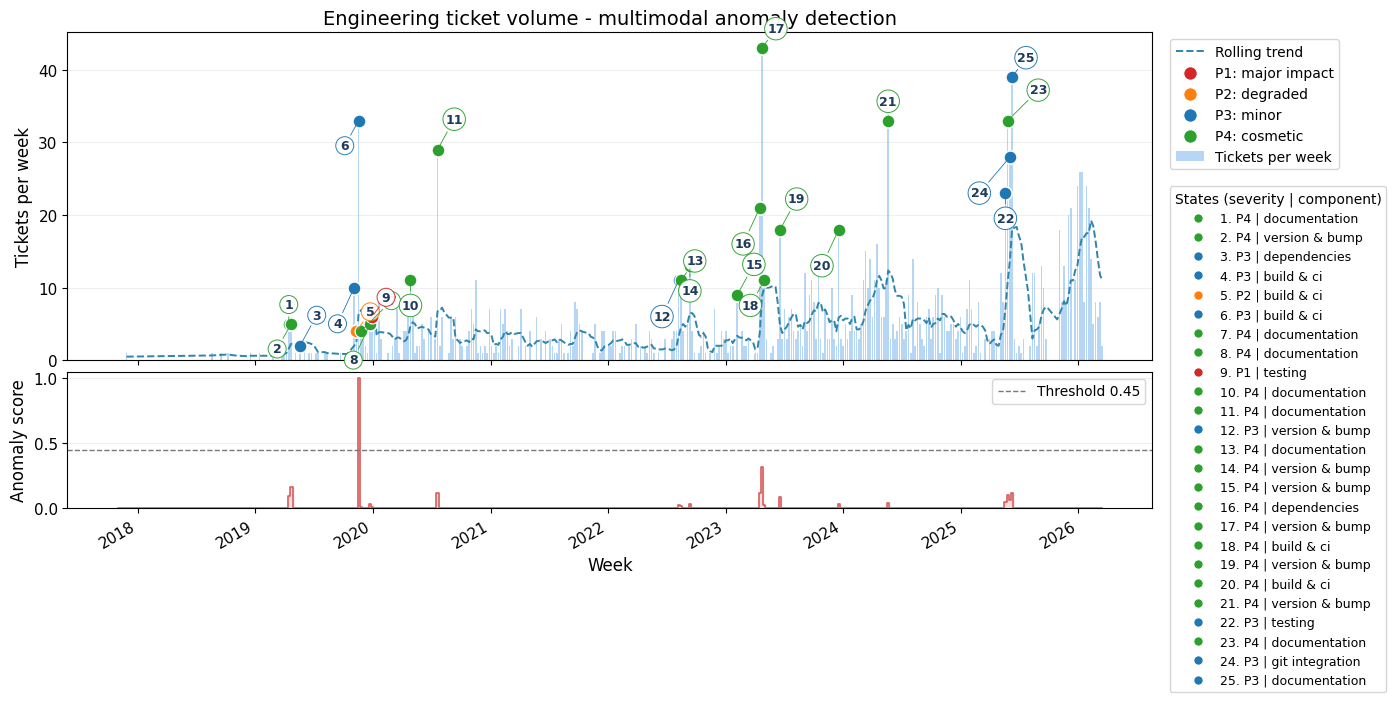

c:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:512: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.78, 0.985])


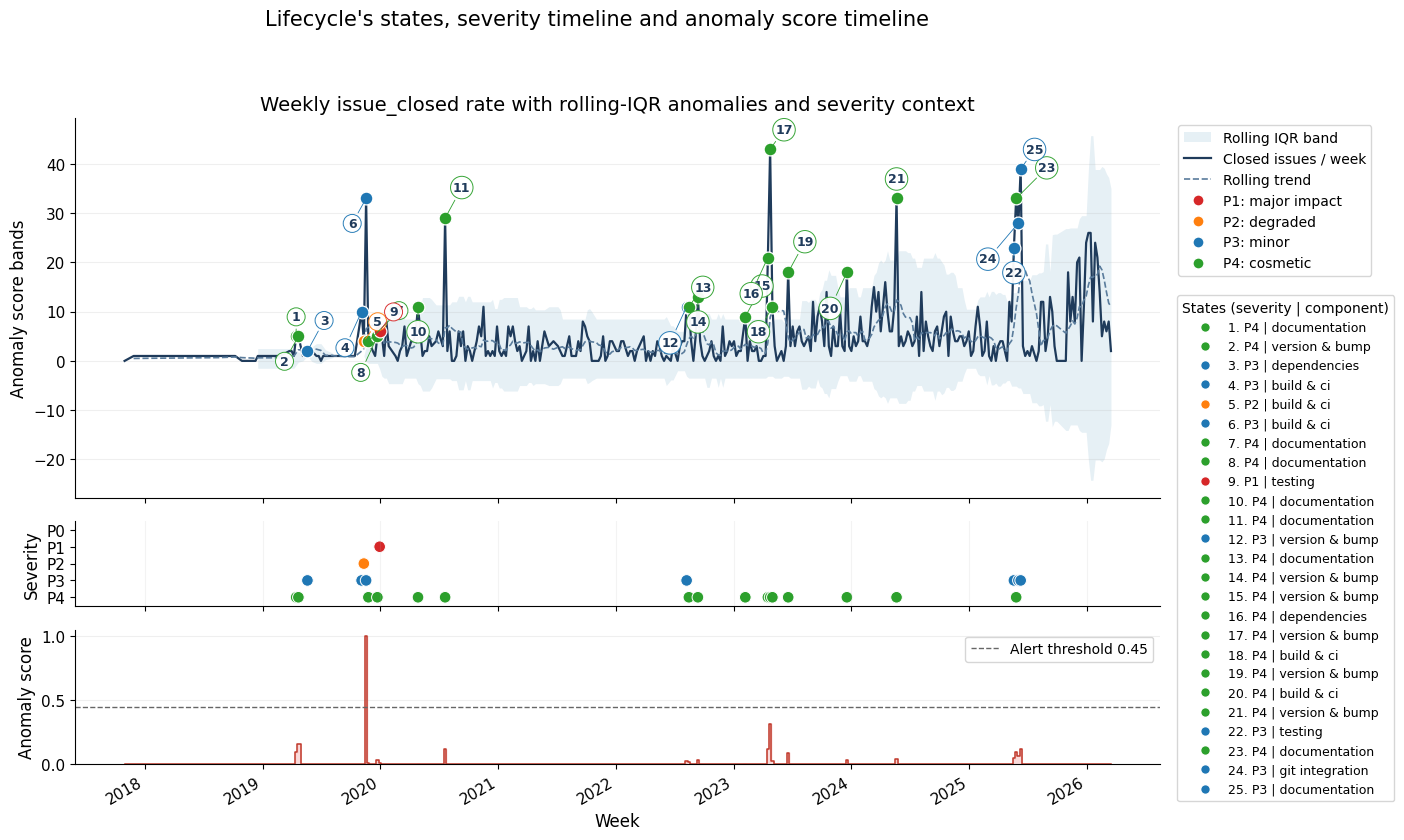

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/commitizen')

In [4]:
from functions.plotting_anomaly import plot_anomaly_figures

plot_anomaly_figures(weekly_closed_anomaly_frame, anomaly_states, cfg)


## 5. Commit context and type classification


commit_context summary: 25 rows x 17 columns
Saved commit_context to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\commitizen\commit_context.csv
commit_typeclass_per_week summary: 25 rows x 33 columns

Mean category ratios across all anomaly weeks:
  feature_work  0.132
  bug_fixes     0.155
  tech_debt     0.497
  docs          0.131
  other         0.086

Mean category ratios by anomaly_direction:
  [high] feature_work=0.132  bug_fixes=0.155  tech_debt=0.497  docs=0.131  other=0.086

Saved commit_typeclass_per_week to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\commitizen\commit_typeclass_per_week.csv


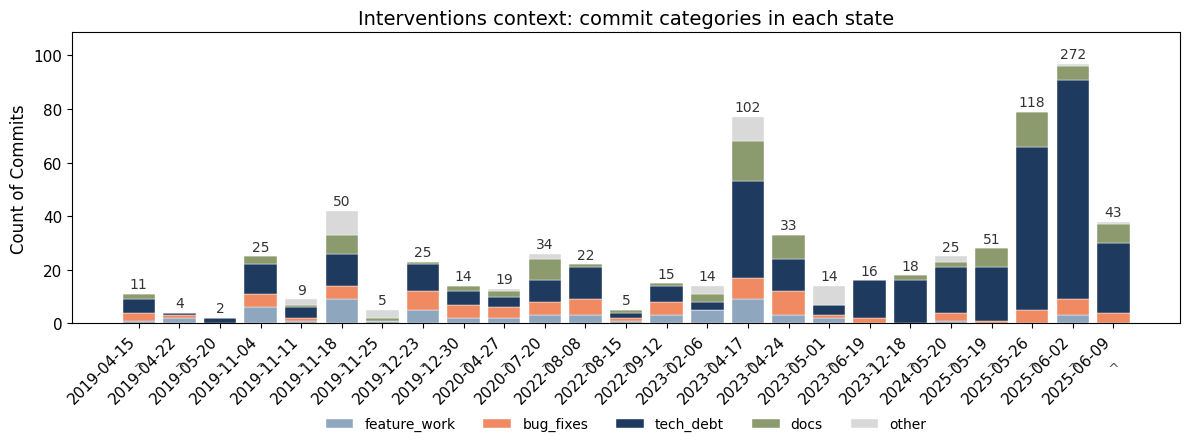

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/commitizen')

In [5]:
from functions.commits import build_commit_context, build_commit_typeclass
from functions.plotting_anomaly import plot_commit_category_stack

commit_context, event_commit_message_join = build_commit_context(
    weekly_closed_anomaly_frame, eventsPerobj_df, objects_attributes, cfg
)
commit_typeclass_per_week = build_commit_typeclass(commit_context, cfg)
plot_commit_category_stack(commit_context, commit_typeclass_per_week, cfg)


## 6. Flatten OCEL2 issue log


In [17]:
from functions.ocel_flatten import flatten_ocel2_issue_log

flat = flatten_ocel2_issue_log(cfg)


Flattened log: 25893 events, 1709 cases
  case:concept:name           concept:name            time:timestamp
0            100019                created 2020-11-21 14:00:43+00:00
1            100019              commented 2020-11-21 14:03:19+00:00
2            100019               reviewed 2020-11-21 14:07:30+00:00
3            100019  head_ref_force_pushed 2020-11-21 15:17:01+00:00
4            100019              committed 2020-11-21 15:31:42+00:00
5            100019  head_ref_force_pushed 2020-11-21 15:31:50+00:00
6            100019                 merged 2020-11-21 15:40:18+00:00
7            100019                 closed 2020-11-21 15:40:18+00:00
8            100062                created 2020-11-21 13:59:15+00:00
9            100062              commented 2020-11-21 14:01:39+00:00


## 7. Vitalizing subset from anomaly object IDs


In [18]:
from functions.ocel_flatten import build_vitalizing_subset

anomaly_events_df, anomaly_df = build_vitalizing_subset(flat, anomaly_object_ids)


Anomaly events df: 6831 rows, 421 cases


## 8. Preprocess + random control (MAX_REP / SEED unchanged)


In [19]:
from functions.preprocessing import build_preprocessed_logs

prep = build_preprocessed_logs(flat, anomaly_events_df, cfg)
flat_df_clean = prep["flat_df_clean"]
vitalizing_df_clean = prep["vitalizing_df_clean"]
random_case_control_df_clean = prep["random_case_control_df_clean"]
clean_log_groups_df = prep["clean_log_groups_df"]
all_cases_clean = prep["all_cases_clean"]
num_vital_cases_clean = prep["num_vital_cases_clean"]


=== Repetition cleaning summary (MAX_REP = 5) ===
Vitalizing: 309 -> 246 cases | 4440 -> 2621 events
Whole: 1302 -> 1097 cases | 17821 -> 11838 events
Random control (rebuilt): 246 cases | 2651 events


## 9. Discovery F1 evaluation on clean logs


In [20]:
from functions.discovery import evaluate_clean_logs

consolidated_results_table_clean, clean_log_groups_eventlog, miners = evaluate_clean_logs(
    clean_log_groups_df, cfg
)
consolidated_results_table_clean.head()


c:\Users\mahsa.choopannezhadm\anaconda3\envs\LCP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
replaying log with TBR, completed traces :: 100%|██████████| 185/185 [00:00<00:00, 347.21it/s]

Expected records: 30 | Observed: 30

7) Consolidated results table in clean logs
               log_name         discovery_method  distinct_traces  \
0   random_case_control            alpha_classic              185   
1            vitalizing            alpha_classic              200   
2                 whole            alpha_classic              668   
3   random_case_control       heuristics_dep_0.6              185   
4            vitalizing       heuristics_dep_0.6              200   
5                 whole       heuristics_dep_0.6              668   
6   random_case_control       heuristics_dep_0.7              185   
7            vitalizing       heuristics_dep_0.7              200   
8                 whole       heuristics_dep_0.7              668   
9   random_case_control       heuristics_dep_0.8              185   
10           vitalizing       heuristics_dep_0.8              200   
11                whole       heuristics_dep_0.8              668   
12  random_case_contro

,log_name,discovery_method,distinct_traces,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,random_case_control,alpha_classic,185,0.660934,0.646611,0.137796,0.227179,100.0,13.0,0.796610,ok,None
1,vitalizing,alpha_classic,200,0.767330,0.682766,0.221668,0.334678,105.0,20.0,0.530864,ok,None
2,whole,alpha_classic,668,0.631486,0.622103,0.121225,0.202910,92.0,10.0,1.000000,ok,None
3,random_case_control,heuristics_dep_0.6,185,0.490330,0.867388,0.507995,0.640736,585.0,39.0,0.459350,ok,None
4,vitalizing,heuristics_dep_0.6,200,0.508117,0.797965,0.651619,0.717405,659.0,50.0,0.444248,ok,None


## 10. Utility figures


Plotting from 30 successful rows
Miner configs: ['alpha_classic', 'heuristics_dep_0.6', 'heuristics_dep_0.7', 'heuristics_dep_0.8', 'heuristics_dep_0.9', 'inductive_IM', 'inductive_IMf_noise_0.3', 'inductive_IMf_noise_0.4', 'inductive_IMf_noise_0.5', 'inductive_IMf_noise_0.6']
Log groups: ['random_case_control', 'vitalizing', 'whole']
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\commitizen\clean_log_f_score_grouped_bars.{png,pdf}


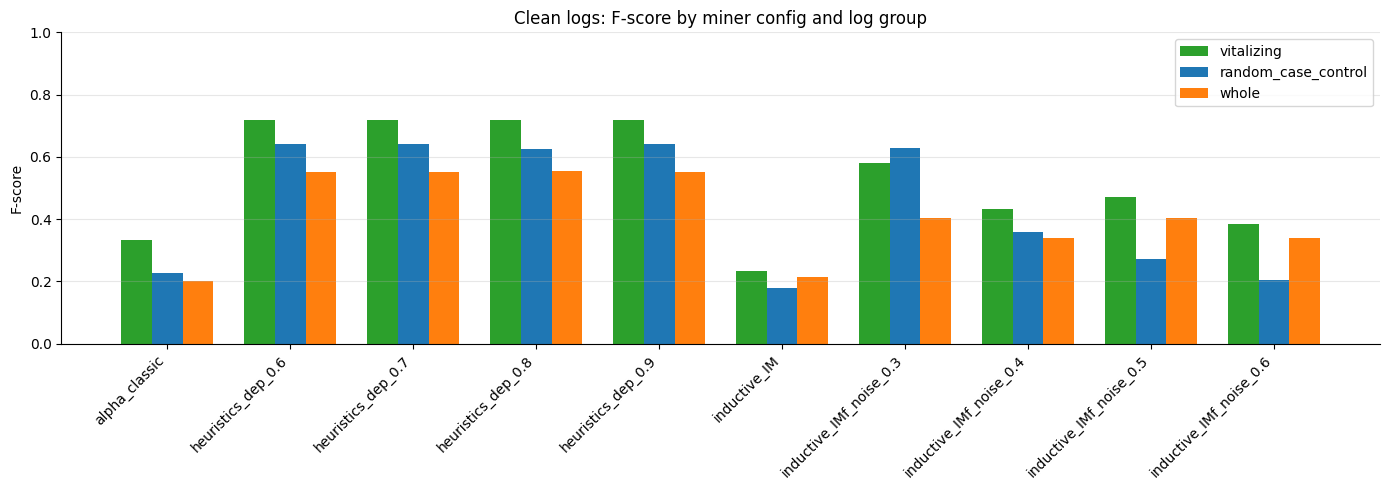

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\commitizen\clean_log_fitness_precision.{png,pdf}


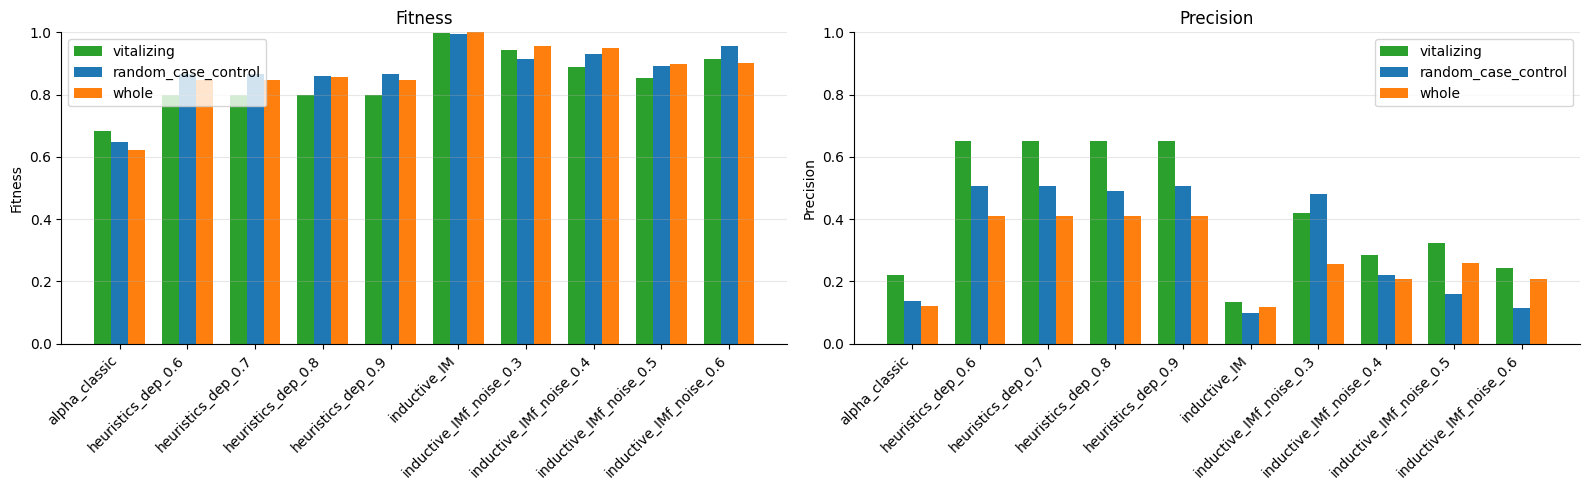

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\commitizen\clean_log_complexity.{png,pdf}


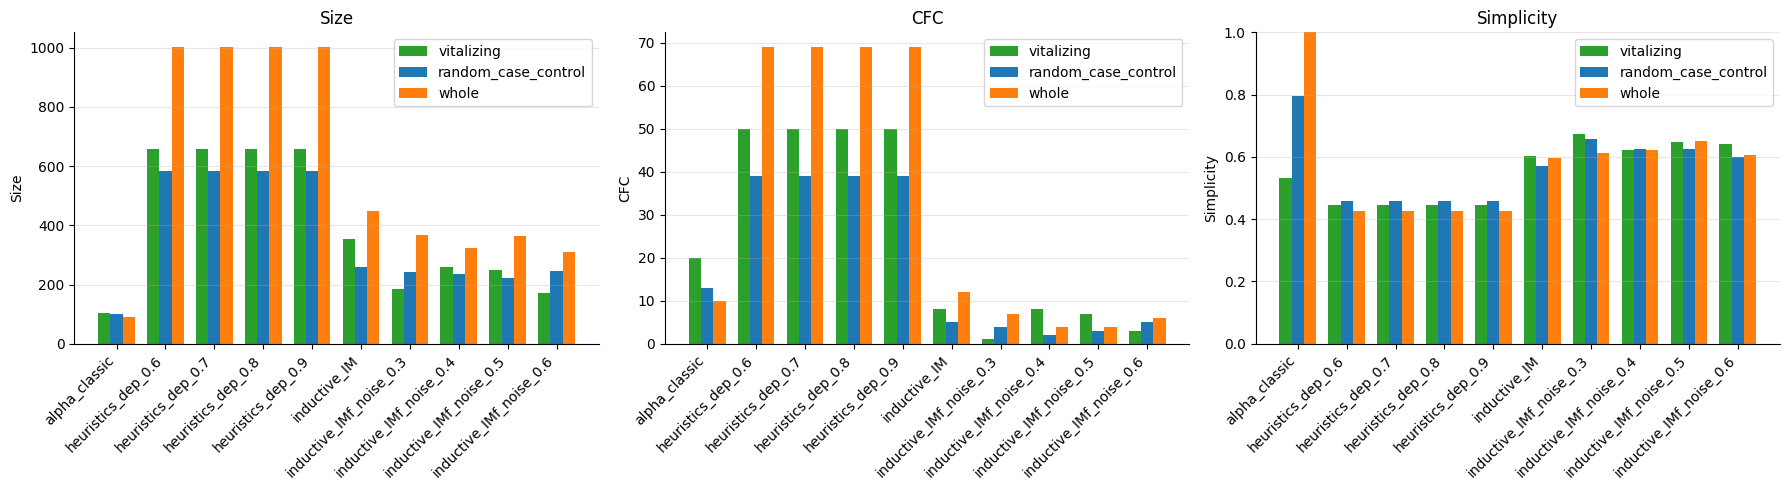

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\commitizen\clean_log_threshold_sensitivity.{png,pdf}


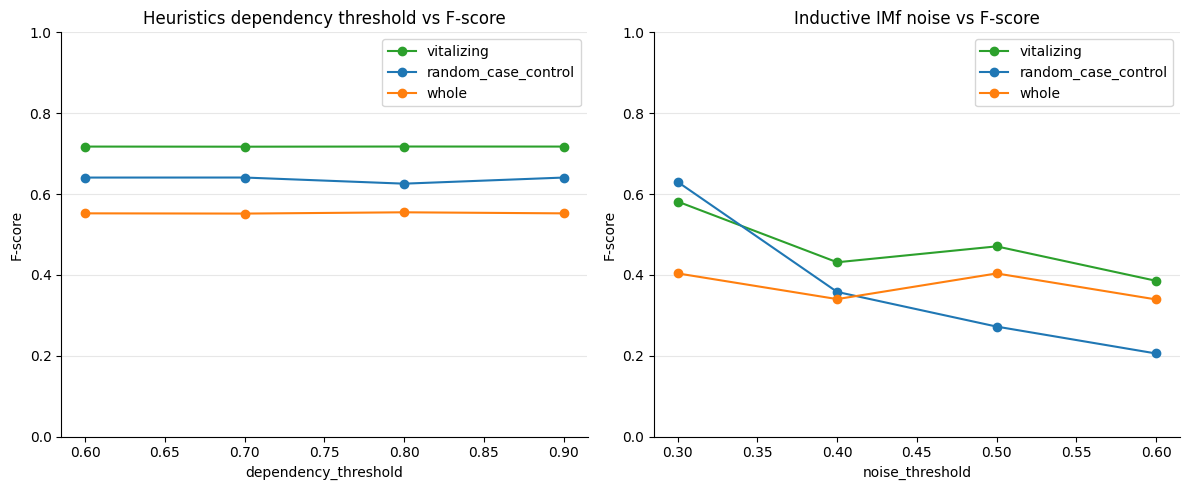

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\commitizen\clean_log_f_score_slopegraph.{png,pdf}


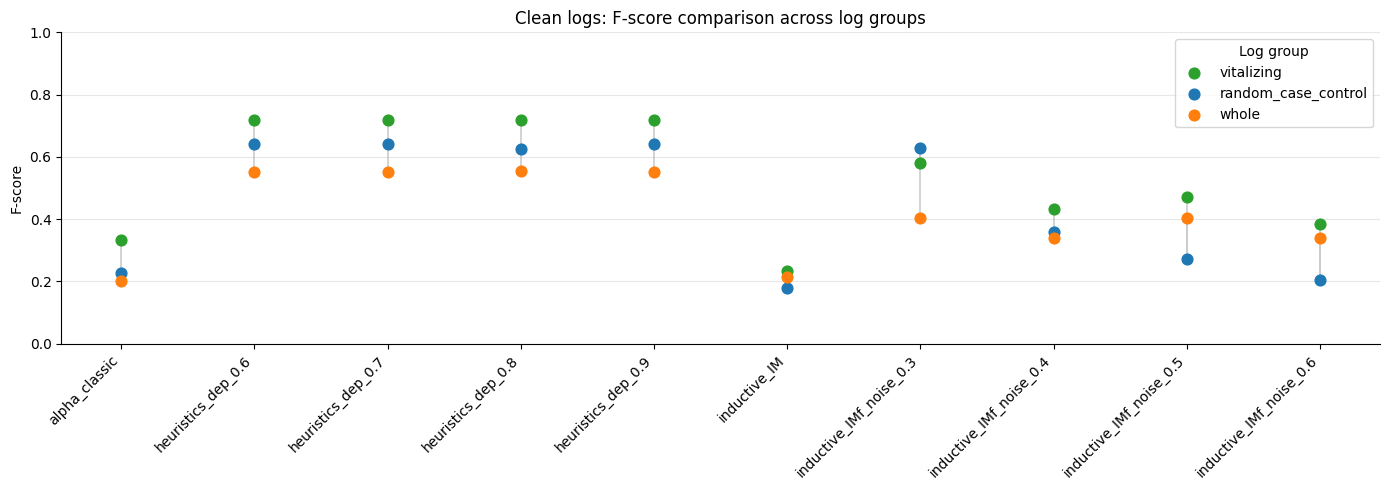

{'wide_f_score_clean': discovery_method     alpha_classic  heuristics_dep_0.6  heuristics_dep_0.7  \
 log_name                                                                     
 random_case_control       0.227179            0.640736            0.640809   
 vitalizing                0.334678            0.717405            0.717118   
 whole                     0.202910            0.552236            0.551645   
 
 discovery_method     heuristics_dep_0.8  heuristics_dep_0.9  inductive_IM  \
 log_name                                                                    
 random_case_control            0.625648            0.640754      0.180527   
 vitalizing                     0.717518            0.717403      0.234796   
 whole                          0.554803            0.552194      0.213320   
 
 discovery_method     inductive_IMf_noise_0.3  inductive_IMf_noise_0.4  \
 log_name                                                                
 random_case_control                 0.62

In [22]:
from functions.plotting_utility import plot_utility_figures

plot_utility_figures(consolidated_results_table_clean, cfg)


## 11. Seed reproducibility


replaying log with TBR, completed traces :: 100%|██████████| 186/186 [00:00<00:00, 369.65it/s]


Reproducibility over 10 seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Discovery metrics summary (mean/std/CV per miner):
          discovery_method  fitness_mean  fitness_std  fitness_cv  \
0            alpha_classic      0.630038     0.074294    0.117920   
1       heuristics_dep_0.6      0.846530     0.010344    0.012220   
2       heuristics_dep_0.7      0.847142     0.011687    0.013795   
3       heuristics_dep_0.8      0.845979     0.012062    0.014258   
4       heuristics_dep_0.9      0.849439     0.012695    0.014945   
5             inductive_IM      0.997088     0.005876    0.005893   
6  inductive_IMf_noise_0.3      0.927629     0.014358    0.015478   
7  inductive_IMf_noise_0.4      0.915164     0.027940    0.030530   
8  inductive_IMf_noise_0.5      0.904312     0.020793    0.022993   
9  inductive_IMf_noise_0.6      0.889508     0.033818    0.038018   

   precision_mean  precision_std  precision_cv  f_score_mean  f_score_std  \
0        0.134598       0.027601      0.205066   

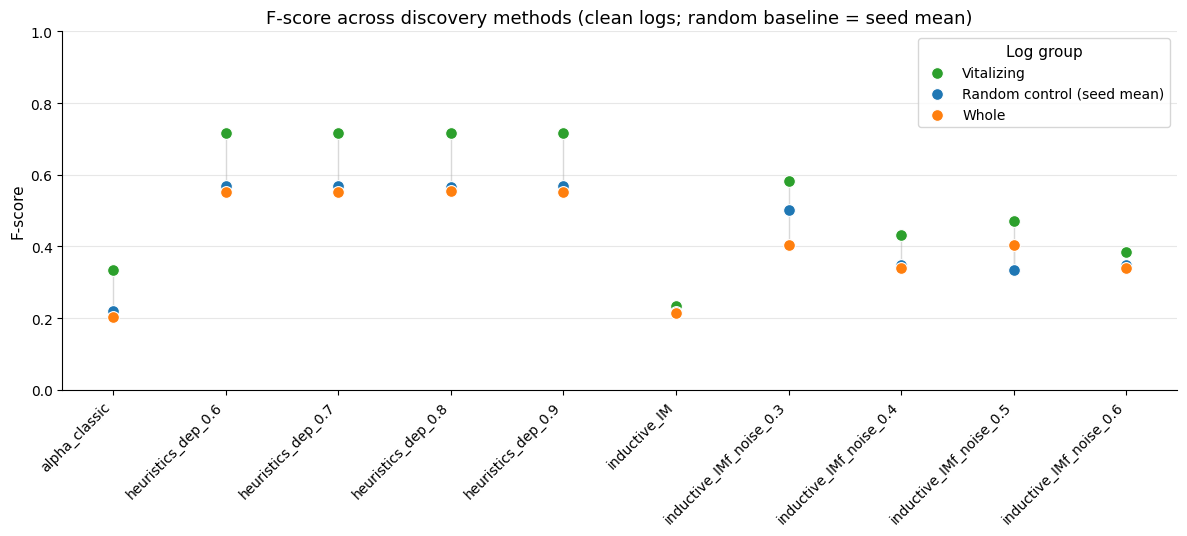

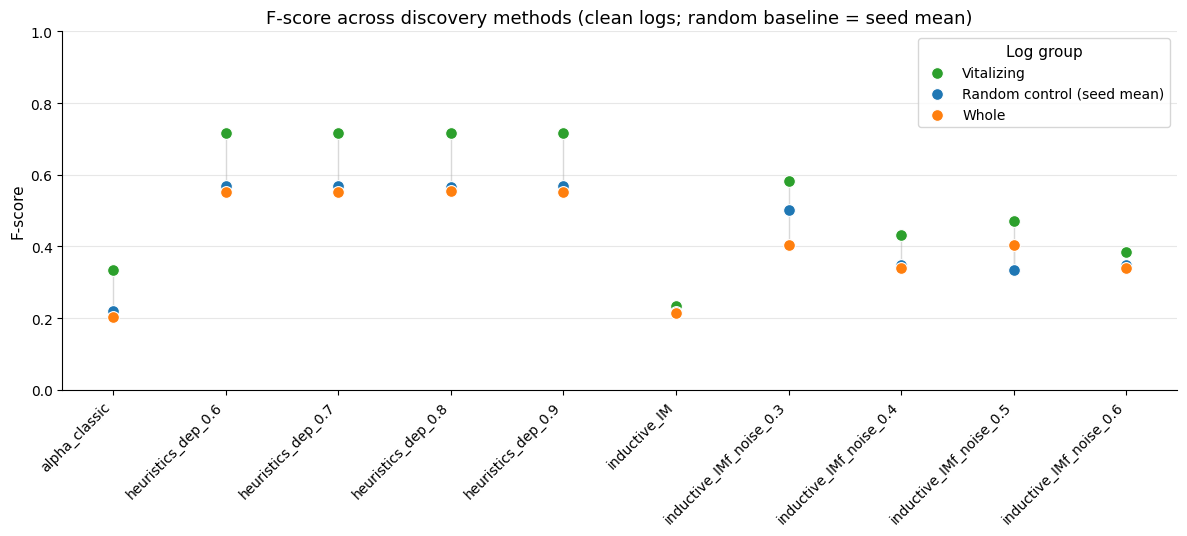

In [23]:
from functions.plotting_utility import plot_repro_slopegraph
from functions.reproducibility import run_seed_reproducibility

repro = run_seed_reproducibility(
    flat_df_clean=flat_df_clean,
    all_cases_clean=all_cases_clean,
    num_vital_cases_clean=num_vital_cases_clean,
    miners=miners,
    consolidated_results_table_clean=consolidated_results_table_clean,
    cfg=cfg,
)
consolidated_results_table_clean_repro = repro["consolidated_results_table_clean_repro"]
plot_repro_slopegraph(consolidated_results_table_clean_repro, cfg)


## 13. Cross-repo f_score comparison

In [2]:
import pandas as pd

from functions.config import RESULTS_TABLES

REPRO_TABLE = "consolidated_results_table_clean_repro.csv"

repro_paths = {p.parent.name: p for p in RESULTS_TABLES.glob(f"*/{REPRO_TABLE}")}

f_score_comparison = pd.concat(
    {
        repo: pd.read_csv(repro_paths[repo])
        .set_index(["discovery_method", "log_name"])["f_score"]
        for repo in sorted(repro_paths, key=str.lower)
    },
    axis=1,
).sort_index()

f_score_comparison.to_csv(RESULTS_TABLES / "f_score_comparison_across_repos.csv")
f_score_comparison

commitizen    FinGPT     FinRL  \
discovery_method        log_name                                              
alpha_classic           random_case_control    0.219680  0.446705  0.290233   
                        vitalizing             0.334678  0.438340  0.352077   
                        whole                  0.202910  0.318998  0.264357   
heuristics_dep_0.6      random_case_control    0.567356  0.751531  0.677409   
                        vitalizing             0.717405  0.744589  0.749855   
                        whole                  0.552236  0.745555  0.572266   
heuristics_dep_0.7      random_case_control    0.568427  0.751531  0.676245   
                        vitalizing             0.717118  0.744589  0.737409   
                        whole                  0.551645  0.743629  0.571236   
heuristics_dep_0.8      random_case_control    0.566093  0.751531  0.676170   
                        vitalizing             0.717518  0.744589  0.749805   
                        whole                  0.554803  0.740286  0.572578   
heuristics_dep_0.9      random_case_control    0.569590  0.751531  0.676125   
                        vitalizing             0.717403  0.744589  0.750436   
                        whole                  0.552194  0.740286  0.572845   
inductive_IM            random_case_control    0.216179  0.609121  0.362824   
                        vitalizing             0.234796  0.625455  0.545173   
                        whole                  0.213320  0.456140  0.331435   
inductive_IMf_noise_0.3 random_case_control    0.501481  0.642580  0.619660   
                        vitalizing             0.581351  0.690538  0.770050   
                        whole                  0.403654  0.623832  0.593466   
inductive_IMf_noise_0.4 random_case_control    0.347862  0.644716  0.507350   
                        vitalizing             0.431205  0.690592  0.770050   
                        whole                  0.340090  0.643317  0.389085   
inductive_IMf_noise_0.5 random_case_control    0.333860  0.652664  0.448472   
                        vitalizing             0.470541  0.740416  0.776283   
                        whole                  0.403574  0.685503  0.410618   
inductive_IMf_noise_0.6 random_case_control    0.349155  0.678865  0.450763   
                        vitalizing             0.385320  0.712434  0.747820   
                        whole                  0.339259  0.685503  0.398365   

                                             Nautilus_trader    OpenBB  \
discovery_method        log_name                                         
alpha_classic           random_case_control         0.273771  0.278927   
                        vitalizing                  0.230088  0.277326   
                        whole                       0.208558  0.305398   
heuristics_dep_0.6      random_case_control         0.566551  0.641106   
                        vitalizing                  0.552776  0.607290   
                        whole                       0.535312  0.641347   
heuristics_dep_0.7      random_case_control         0.566410  0.640366   
                        vitalizing                  0.553704  0.607034   
                        whole                       0.535390  0.637279   
heuristics_dep_0.8      random_case_control         0.566447  0.640308   
                        vitalizing                  0.551823  0.607673   
                        whole                       0.534912  0.637254   
heuristics_dep_0.9      random_case_control         0.566814  0.640606   
                        vitalizing                  0.552538  0.607242   
                        whole                       0.534917  0.642238   
inductive_IM            random_case_control         0.265851  0.293377   
                        vitalizing                  0.218282  0.348035   
                        whole                       0.215220  0.310494   
inductive_IMf_noise_0.3 random_case_

## 14. F1 dot plot per miner across repos

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\figures\f_score_dotplot_by_miner.{png,pdf}


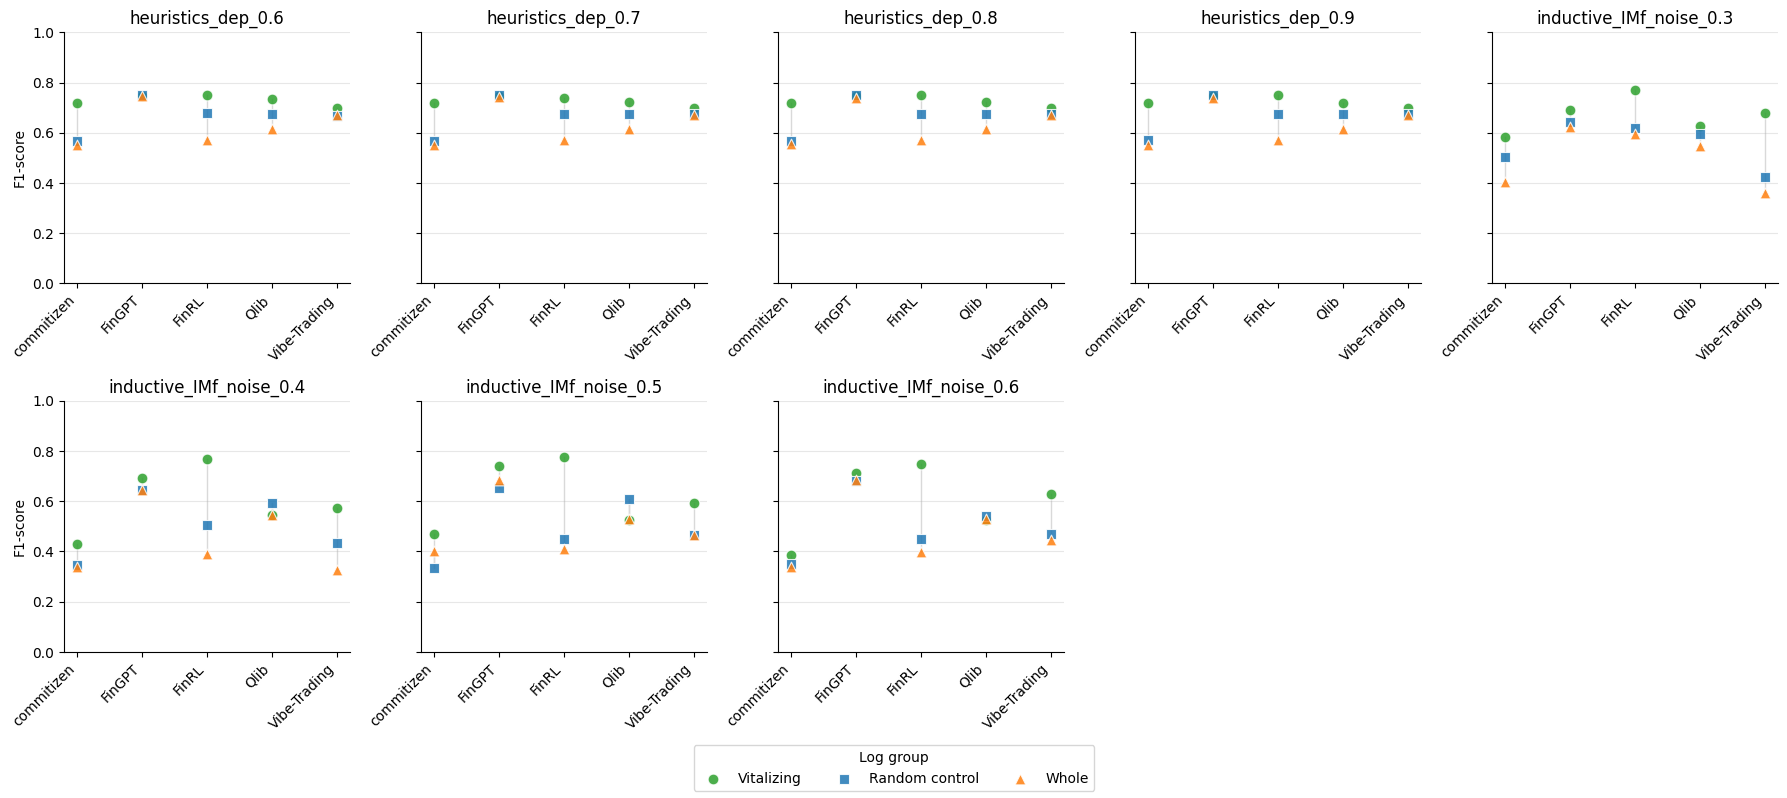

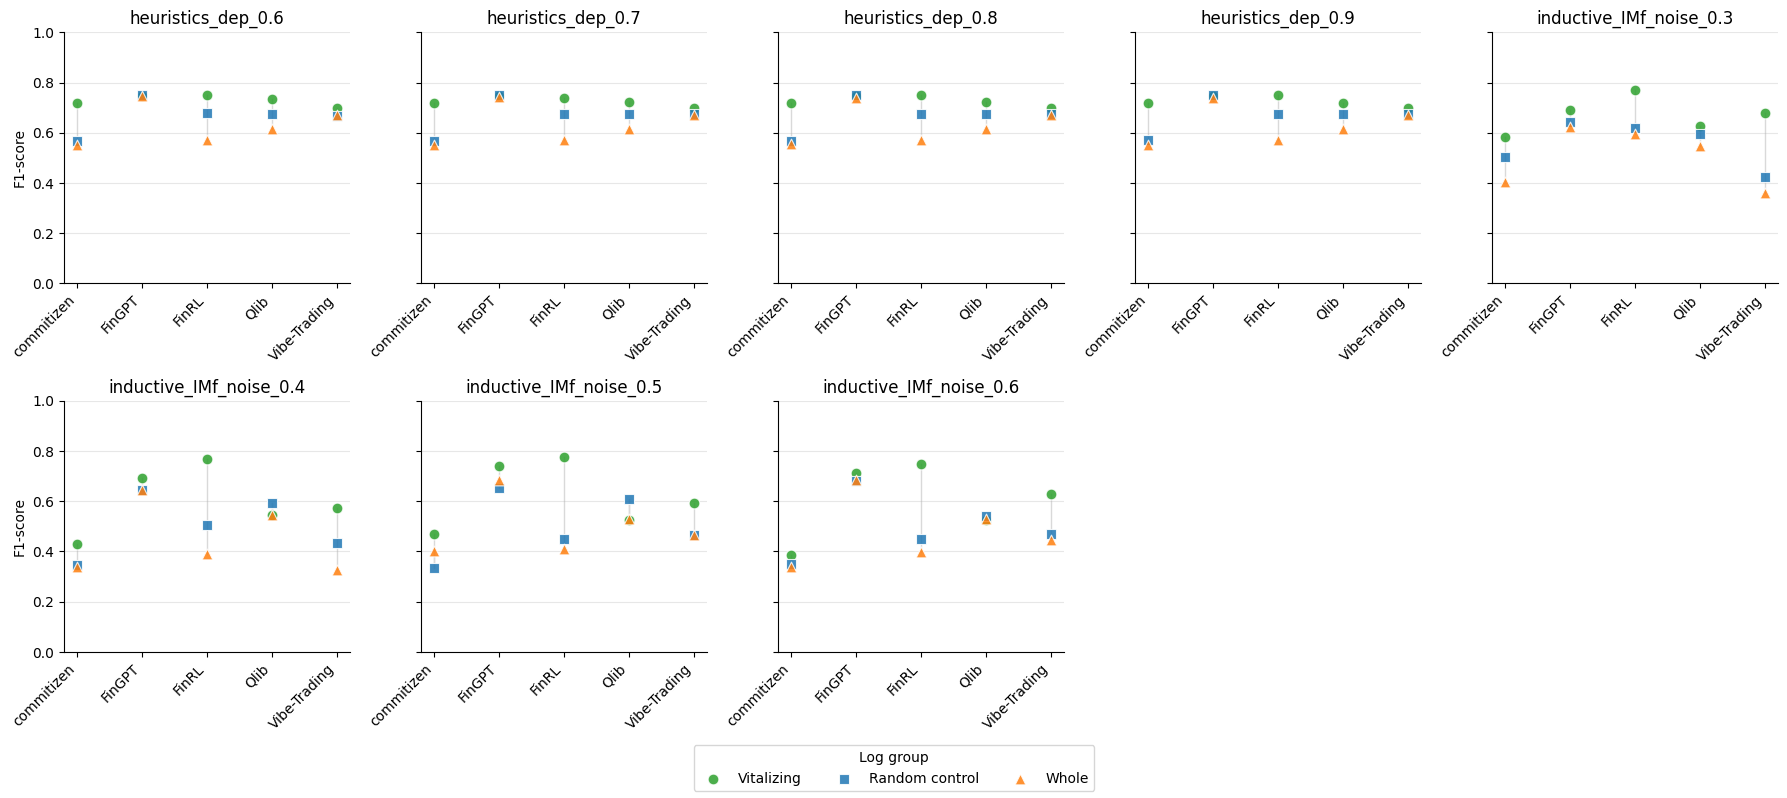

In [3]:
from functions.plotting_utility import plot_f_score_dotplot_by_miner_different_repos

# choosing repos from  this list.
repos_to_plot = [
    "commitizen",
    "FinGPT",
    "FinRL",
    "Qlib",
    "Vibe-Trading",
    #"OpenBB",
    #"TradingAgents",
    #"Nautilus_trader"
]

# choosing discovery algorithms from this list.
discovery_methods_to_plot = [
    #"alpha_classic",
    #"inductive_IM",
    "heuristics_dep_0.6",
    "heuristics_dep_0.7",
    "heuristics_dep_0.8",
    "heuristics_dep_0.9",
    "inductive_IMf_noise_0.3",
    "inductive_IMf_noise_0.4",
    "inductive_IMf_noise_0.5",
    "inductive_IMf_noise_0.6",
]

plot_f_score_dotplot_by_miner_different_repos(
    f_score_comparison,
    repos=repos_to_plot,
    discovery_methods=discovery_methods_to_plot,
)